## **DNLS Model Learned by SREINet**


## **I. Setup and Preprocessing**


In [1]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG

# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0. Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

Guess highest order polynomial: 3
(160000, 50)


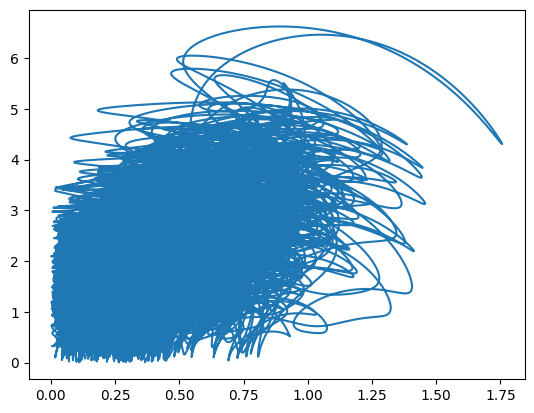

Training input shape: (160000, 100)
Training output shape: (160000, 100)


In [2]:
# Specify the model type
MY_MODEL = 'dnls'  

SEED = 42  # set seed for random number generation
np.random.seed(SEED)

# Generate data based on the specified model type
node_num = 50
C = 2.0 #coupling strength
xn = np.linspace(-node_num/2/np.sqrt(C), node_num/2/np.sqrt(C), node_num)
  
num_traj = 16
v = np.linspace(0.0, 0.99, num_traj)
data_initial_conditions= []
for i in range(num_traj):
        
        #trajectory shape 1
        amp = np.random.normal(0, 0.5, node_num)
        phase = np.random.uniform(0, 2*np.pi, node_num)
        new_IC = amp*np.cos(phase) + 1j*amp*np.sin(phase)
        data_initial_conditions.append(new_IC)
        

data_T =  100.0       # Length of the data (T)
data_dt = 0.01       # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions,T=data_T, dt=data_dt, random_state=SEED)
t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(MY_MODEL, C, node_num, method="DOP853")

print("Guess highest order polynomial:", guess_highest_order_polynomial)

import matplotlib.pyplot as plt
print(x_train.shape)
plt.plot(np.abs(x_train[:,0]), np.abs(dx_train[:,0]))
plt.show()

x_train = np.concatenate((np.real(x_train), np.imag(x_train)), axis=1)
dx_train = np.concatenate((np.real(dx_train), np.imag(dx_train)), axis=1)
training_input, training_output = x_train, dx_train

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

### **1.3 Hyperparameters**

In [4]:
# Set mini-batch size
MINI_BATCH_SIZE = 512
learning_rate = 0.005

### **1.4 Model Architecture Definitions**

**SREINet Parameters**

In [5]:
# Assign dim to be the 2nd dimension of the training data (number of input variables)
dim = training_input.shape[1] 

# The grid size of each dimension
layer_depth = guess_highest_order_polynomial
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn) # excluding the constant term; NOT the total number of neurons per layer

[100, 100, 100]


## **II. Model and Training Preparation**

### **2.1 Create the SREINet Model**

In [6]:
activation_fns = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 
                     activations=activation_fns,
                     data_type=MY_DATA_TYPE,
                     weight_initializer=tf.initializers.RandomNormal(stddev=1e-4, seed=SEED),
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)


### **2.2 Loss Function**

In [7]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive). We found MSE is the best.

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [8]:
#my_optimizer = tf.keras.optimizers.Adam() 
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Defining the Training Loop**


In [9]:
from sreinet_trainer import *

trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**

#### **Setup of Pruning Profile**


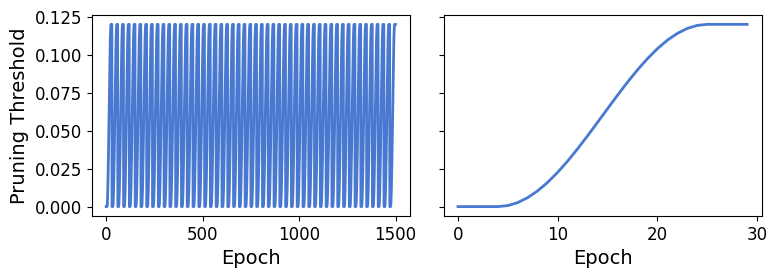

In [10]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.12
N_PERIODS = 50
PRUNING_EPOCHS_PER_PERIOD = 30
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    zero_percentage=0.15,
                    show_plot=True)


#### **Training**


In [11]:
EARLY_STOPPING_LOSS_THRESHOLD = 1e-10   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.05 # Threshold for early stopping (Pruning Based)

training_histories = []
weights_list = []
loss_list = []
print(f"Total Dimensions: {training_output.shape[1]}")
for i in range(training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.20,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     patience_periods=20,
     verbose=1,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)

Total Dimensions: 100
Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 4.128e-01,  Validation Loss: 2.425e-01,  Epoch Time: 0.87s,  Current Pruning Threshold: 0
Epoch   2 (Period 1):  Train Loss: 3.362e-02,  Validation Loss: 1.734e-01,  Epoch Time: 0.67s,  Current Pruning Threshold: 0
Epoch   3 (Period 1):  Train Loss: 9.601e-03,  Validation Loss: 1.586e-01,  Epoch Time: 0.69s,  Current Pruning Threshold: 0
Epoch   4 (Period 1):  Train Loss: 4.385e-03,  Validation Loss: 1.524e-01,  Epoch Time: 0.62s,  Current Pruning Threshold: 0
Epoch   5 (Period 1):  Train Loss: 2.487e-03,  Validation Loss: 1.476e-01,  Epoch Time: 0.65s,  Current Pruning Threshold: 0
Epoch   6 (Period 1):  Train Loss: 2.405e-03,  Validation Loss: 1.459e-01,  Epoch Time: 0.61s,  Current Pruning Threshold: 0.00067015
Epoch   7 (Period 1):  Train Loss: 3.602e-03,  Validation Loss: 1.394e-01,  Epoch Time: 0.59s,  Current Pruning Threshold: 0.0026656
Epoch   8 (Period 1):  Train Loss: 4.070e-03,  Validation Loss

## **IV. Coefficient Reconstructor (SREINet)**

After training, we fomulate the identified model by reconstructing SREINet's coefficients.


#### `generate_set_labels`
This function generates the labels for the neurons in the SREINet and the LHS of the ODEs.

In [12]:
def generate_layer_labels(N):
    N = int(N/2)
    return ['Constant'] + [f'a{i}' for i in range(1, N+1)] + [f'b{i}' for i in range(1, N+1)]
def generate_LHS_labels(N):
    N = int(N/2)
    return [f"(a{i})'" for i in range(1, N+1)] + [f"(b{i})'" for i in range(1, N+1)]

#### `coefficient_reconstruction`

In [13]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results**
### **Identified Model**

In [22]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-3,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(a1)' =  - 1.000000047*a1^2*b1 + 4.000000056*b1 - 1.000000109*b1^3 - 2.000000028*b2 - 2.000000028*b50
(a2)' =  - 2.000000561*b1 + 4.00000031*b2 - 2.000000358*b3 - 0.9999975604*a2^2*b2 - 0.9999992888*b2^3
(a3)' =  - 0.9999999706*a3^2*b3 - 2.000000018*b2 + 4.000000036*b3 - 1.000000054*b3^3 - 2.000000018*b4
(a4)' =  - 2.000000022*b3 + 4.000000045*b4 - 1.000000098*a4^2*b4 - 1.000000072*b4^3 - 2.000000022*b5
(a5)' =  - 2.000000065*b4 + 4.00000013*b5 - 2.000000065*b6 - 0.9999999649*a5^2*b5 - 1.000000008*b5^3
(a6)' =  - 2.000000075*b5 + 4.00000015*b6 - 2.000000075*b7 - 0.9999992379*a6^2*b6 - 1.00000015*b6^3
(a7)' =  - 2.000000029*b6 + 4.000000059*b7 - 2.000000029*b8 - 0.9999999117*a7^2*b7 - 1.000000023*b7^3
(a8)' =  - 2.000000076*b7 + 4.000000151*b8 - 2.000000076*b9 - 0.9999999267*a8^2*b8 - 0.9999999858*b8^3
(a9)' =  - 2.000000051*b8 + 4.000000101*b9 - 2.000000051*b10 - 0.9999999917*a9^2*b9 - 1.000000006*b9^3
(a10)' =  - 1.999999998*b9 + 3.999999996*b10 - 1.999999998*b11 - 0.9999999545*a10^2*

### **Validation**


In [ ]:
import importlib

import model_reconstructor as mr

recovered_model = mr.RecoveredModel()
recovered_model.parse_ode_equations(eq_str) #parse string to ode function

### Comparing vector field

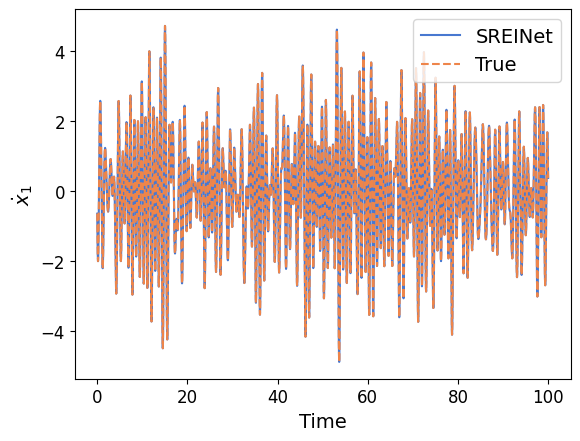

In [45]:
pred_x_dot = recovered_model.predict_derivatives(x_train)

val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)


import matplotlib.pyplot as plt

plt.plot(val_t_eval, pred_x_dot[:val_t_eval.shape[0], 0],label='SREINet')
plt.plot(val_t_eval, dx_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel(r'$\dot{x}_1$')
plt.legend()
plt.show()


### Comparing response

In [46]:

val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

ic = recovered_model.split_complex_initial_conditions(data_initial_conditions[0])

validation_result = recovered_model.simulate(ic, t_span=val_t_span,t_eval=val_t_eval, method='DOP853')

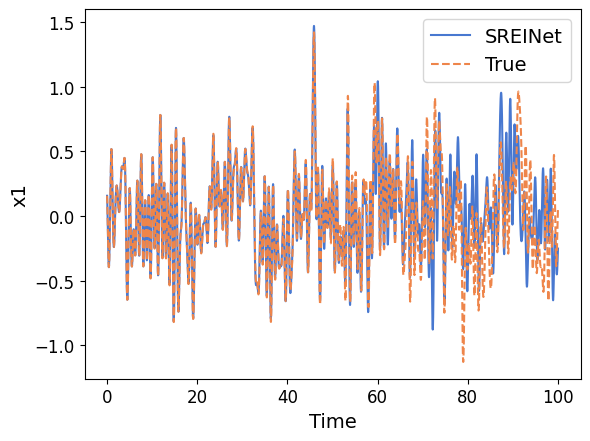

In [47]:
import matplotlib.pyplot as plt

plt.plot(validation_result['t'], validation_result['y'][0],label='SREINet')
plt.plot(val_t_eval, x_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel('x1')
plt.legend()
plt.show()

In [52]:
score =recovered_model.score(x_train[:val_t_eval.shape[0]], dx_train[:val_t_eval.shape[0]])
print(f"Score: {score}")

complexity = recovered_model.calculate_complexity()
print(f"Complexity: {complexity}") # number of nonzero terms 

complexity_per_dimension = complexity // dim
print(f"Complexity per dimension: {complexity_per_dimension}")

Score: 0.9999999999999897
Complexity: 500
Complexity per dimension: 5


## **VI. Output**

In [49]:
#save hyperparameters
import pandas as pd

df = pd.DataFrame({
    'ODE model': [MY_MODEL],
    'data initial conditions': [data_initial_conditions],
    'data length (T)': [data_T],
    'data resolution (dt)': [data_dt],
    'learning rate': [learning_rate],
    'layer depth': [layer_depth],
    'input dimension': [x_train.shape[1]],
    'mini_batch_size': [MINI_BATCH_SIZE],
    'Layer Neurons per activation fns': [layer_neuron_nums_per_act_fn],
    'Data Points': [training_input.shape[0]],
    'Total Training Epochs': [NUM_EPOCHS],
    'loss function': [LOSS_FUNCTION],
    'Best loss values': [str(loss_list)], 
    'max weight threshold for pruning': [MAX_WEIGHT_PRUNING_THRESHOLD],
    'loss threshold for early stopping': [EARLY_STOPPING_LOSS_THRESHOLD],
    'pruning epochs per period': [PRUNING_EPOCHS_PER_PERIOD],
    'number of training periods': [N_PERIODS],
})

In [50]:
# Import the output helper module
import output_helper as opt_helper

# Save all results to Excel using the helper function
filepath = opt_helper.save_sreinet_results_to_excel(
    config_df=df,
    training_histories=training_histories,
    recovered_model=recovered_model,
    filename='DNLS_nn_configurations.xlsx',
    output_dir='output'
)

Successfully saved SREINet results to: output/DNLS_nn_configurations.xlsx
